# Split-Sample Validation

## What Is Split-Sample Validation?

<span style="color:#1f77b4">**Split-sample validation**</span> (also called the <span style="color:#1f77b4">**hold-out method**</span>) tackles overfitting head-on by reserving part of the data for evaluation. The <span style="color:#ff7f0e">**test set**</span> is not used in model training, and thus evaluation on the <span style="color:#ff7f0e">**test set**</span> shall properly reflect the tendency of overfitting when applied to a new dataset. 

---

### How It Works

1. <span style="color:#1f77b4">**Random Split**</span>
   Divide the dataset once into two* portions:

   * <span style="color:#2ca02c">**Training set**</span> $q\%$ (e.g., 70 to 90%)
   * <span style="color:#ff7f0e">**Test set**</span> – the remaining $(1-q)\%$

   Randomization ensures that both sets are drawn from the same data-generating mechanism.

   **Warning**: If the data have structure (time series, spatial correlations, grouped labs, etc.), use a *structured* split so that data leakage doesn't occur.

2. Model Training
   Explore and train **any** models you would like to on the <span style="color:#2ca02c">**training set**</span>

3. Model Evaluation
   Evaluate each trained model on the <span style="color:#ff7f0e">**test set**</span> once (e.g., estimate the RMSE of the predicted results on the <span style="color:#ff7f0e">**test set**</span>)
   

4. <span style="color:#2ca02c">**Final Fit**</span>
   Pick the model with the best performance (e.g., lowest RMSE or highest accuracy).
   Refit the chosen model on the **entire dataset** before deployment.

*: Sometimes one might devide the data into three or more portions: training set, validation set, and test set. Here the validation set correspond to test set in the training-test split (for choosing models), and the new test set is the set to obtain the performance of the chosen model in the wild. 

--- 

### Why It Works?

The training never involves the test data, so performance evaluated on the <span style="color:#ff7f0e">**test set**</span> mimics performance on truly new data.

---

### Pros and Cons

✅ Straightforward concept & implementation.   
✅ Fast 

❌ Wastes data for training  
❌ Performance estimate can be noisy with a small <span style="color:#ff7f0e">**test set**</span>                                        




Check out this (very interesting) illustration from [MLU](https://mlu-explain.github.io/train-test-validation/).

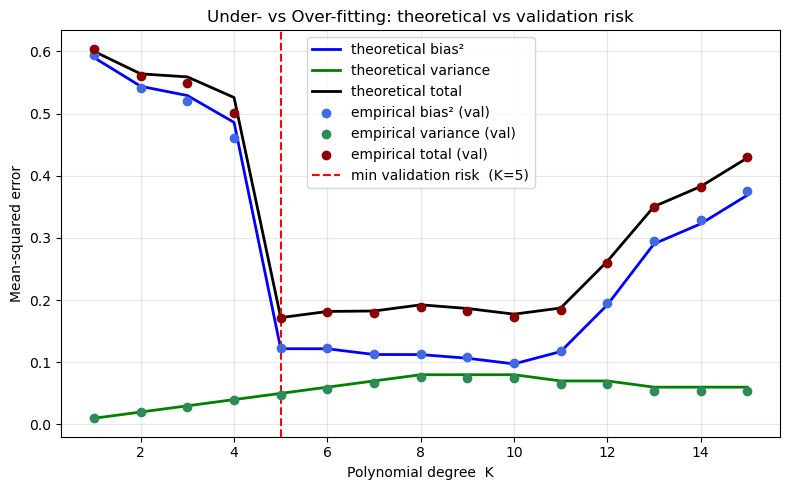

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# What this simulation shows, in terms of the algorithm in 'How It Works':
#   the 20-point validation grid below plays the role of the TEST set (Step 1's
#   held-out portion); models of every polynomial degree K are trained on the
#   100 training points (Step 2); each is scored on the validation points
#   (Step 3); and the degree with the lowest validation risk is the pick
#   (Step 4).  Because the data are simulated, we ALSO know the theoretical
#   bias^2/variance curves -- so we can see how well the validation estimate
#   tracks the truth.

# 1 · true function and deterministic training grid -----------------
n_train = 100
x_train = np.linspace(0, 4, n_train)
f_true  = np.sin(np.pi * x_train) + 0.5*np.sin(2*np.pi * x_train)
sigma2  = 1.0                    # noise variance

def poly_design(x, K):
    return np.column_stack([x**k for k in range(1, K+1)])

# 2 · theoretical bias² & variance on the *training* grid -----------
# (the 'truth' that Step 3's test-set estimate is trying to recover)
def theo_components(K):
    X = poly_design(x_train, K)
    H = X @ np.linalg.pinv(X.T @ X) @ X.T
    bias2 = np.mean(((np.eye(n_train) - H) @ f_true) ** 2)
    var   = sigma2 * np.trace(H @ H.T) / n_train
    return bias2, var, bias2 + var

Kmax = 15
Ks   = np.arange(1, Kmax+1)
bias_t, var_t, tot_t = zip(*(theo_components(k) for k in Ks))

# 3 · Monte-Carlo validation risk on *independent* 20-point set -----
# (Step 3 of the algorithm: evaluate on data the training never touched;
#  note how small the validation set is -- only 20 points -- which is
#  exactly the 'noisy estimate' situation in the Cons list)
n_val   = 20
n_sims  = 2_000
rng     = np.random.default_rng(0)

# storage for empirical curves
val_risk   = np.zeros((Kmax,))
val_bias2  = np.zeros((Kmax,))
val_var    = np.zeros((Kmax,))

# fix validation x once; draw fresh noise every sim
x_val = np.linspace(0.1, 3.9, n_val)           # evenly-spaced validation grid
f_val = np.sin(np.pi * x_val) + 0.5*np.sin(2*np.pi * x_val)

for K in Ks:
    preds = np.zeros((n_sims, n_val))
    Xtr   = poly_design(x_train, K)
    Xv    = poly_design(x_val,   K)
    P     = Xv @ np.linalg.pinv(Xtr.T @ Xtr) @ Xtr.T  # maps train y → val preds

    # Monte-Carlo loop (vectorised)
    # (Step 2, repeated 2000 times: each sim is one 'training' on a fresh
    #  noisy draw of y; Step 3: its error on the validation grid)
    eps   = rng.normal(size=(n_sims, n_train))
    y_tr  = f_true + eps
    preds = y_tr @ P.T           # (2k sims × n_val)
    # empirical quantities
    val_risk[K-1]  = np.mean((preds - f_val)**2)
    val_bias2[K-1] = np.mean((preds.mean(axis=0) - f_val)**2)
    val_var[K-1]   = np.mean(preds.var(axis=0))

# 4 · plot ----------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(Ks, bias_t, label="theoretical bias²",   color="blue", lw=2)
plt.plot(Ks, var_t,  label="theoretical variance",color="green",lw=2)
plt.plot(Ks, tot_t,  label="theoretical total",   color="black",lw=2)

plt.scatter(Ks, val_bias2, marker="o", color="royalblue",
            label="empirical bias² (val)", zorder=3)
plt.scatter(Ks, val_var,   marker="o", color="seagreen",
            label="empirical variance (val)", zorder=3)
plt.scatter(Ks, val_risk,  marker="o", color="darkred",
            label="empirical total (val)", zorder=3)

# Step 4 (model selection): the degree with the lowest validation risk
best_k = Ks[np.argmin(val_risk)]
plt.axvline(best_k, ls="--", color="red",
            label=f"min validation risk  (K={best_k})")

plt.xlabel("Polynomial degree  K")
plt.ylabel("Mean-squared error")
plt.title("Under- vs Over-fitting: theoretical vs validation risk")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.show()
